# 04 — Event Study & Causal Analysis

**DATSCI7030 · Causal Event-Driven Market Impact Modelling**
Author: Ibrahim Haroun · LJMU 2025–2026 · Version 2.1
Updated 2026-07-06 (Final Notebook Alignment): fixed a `vix.parquet` schema-drift bug (`vix` → `vix_close`, same root cause as the Notebook 03 `fomc_dates.parquet` fix), added full purpose/scope/interpretation/validation/handoff structure to match `03_event_detection.ipynb`'s style standard, and qualified "lexicon primary" language against Sentiment Engine Freeze v1.0 (`10_decision_log.md`).

---

## Purpose

Isolate the **causal** market impact of presidential/FOMC events, distinguishing correlation (event-study CAR) from causation (DoWhy backdoor estimation) — the primary evidence base for **RQ1**.

## Inputs

| File | Role |
|------|------|
| `data/processed/events_tagged.parquet` | Event catalogue (Notebook 03 output) — event type, sentiment, high-impact flag |
| `data/processed/daily_sentiment.parquet` | Daily aggregate sentiment (Notebook 03 output) |
| `data/processed/high_impact_events.parquet` | High-impact event subset (Notebook 03 output) |
| `data/raw/spy_ohlcv.parquet` | SPY daily OHLCV — event-study return series |
| `data/raw/vix.parquet` | VIX — confounder for the causal model (`vix_close` column, aliased to `vix` internally) |

## Outputs

| File | Role |
|------|------|
| `data/processed/car_results.parquet` | Event-level CAR/AR records (1,796 rows) |
| `data/processed/causal_estimates.parquet` | DoWhy backdoor causal effect per event type |
| `reports/figures/04a_car_by_event_type.png` … `04d_car_regime_sentiment.png` | RQ1 evidence figures |

## Research Questions Supported

**RQ1** (primary) — both the event study (CAR/CAAR significance testing) and the causal analysis (DoWhy backdoor estimate + refutation tests) answer RQ1, per `01_research_questions.md` and `rq_traceability.svg`. Not RQ2/RQ3.

## Pipeline Position

`03_event_detection.ipynb` → **`04_causal_analysis.ipynb`** → `05_feature_engineering.ipynb`. This notebook does not read `data/processed/master_dataset.parquet` (a separate, frozen artefact built in parallel from Notebook 03's outputs — see `dataset_contract.md`) — it builds its own local `master` daily frame directly from raw SPY/VIX and Notebook 03's processed outputs, matching this notebook's own historical inputs at the time `car_results.parquet`/`causal_estimates.parquet` were frozen.

## Scope — this notebook DOES

- Merge event catalogue with SPY returns and VIX into a local daily frame
- Compute Abnormal Returns (AR) and Cumulative Abnormal Returns (CAR) via a market-model event study
- Significance-test CAR against zero (t-test, Wilcoxon) by event type
- Specify and estimate a DoWhy backdoor causal model (treatment → outcome, with VIX regime and prior-day return as confounders)
- Run refutation tests (random common cause, placebo treatment, data subset)
- Repeat the causal estimate with FinBERT sentiment as a robustness check
- Save and visualise CAR/causal results

## Scope — this notebook does NOT

- Perform event detection, classification, or sentiment scoring (Notebook 03's job)
- Perform feature engineering for predictive modelling (Notebook 05's job)
- Train any predictive ML model
- Modify `master_dataset.parquet`, `feature_matrix.parquet`, or any other frozen artefact

**Sentiment strategy (historical, pre-Sentiment Engine Freeze v1.0):**
- **Primary treatment** → Lexicon `sentiment_numeric` (better domain coverage on this sample, 27% non-neutral) — this is how `causal_estimates.parquet` was actually computed and frozen; it is **not** re-run here.
- **Robustness check** → FinBERT `sentiment_numeric` (financial NLP benchmark, 5% non-neutral)
- **Note (SEF v1.0, 2026-07-06):** FinBERT is now the project's official primary sentiment engine project-wide (`10_decision_log.md`). This notebook's *already-frozen* causal estimate used lexicon sentiment as its treatment variable at the time it was computed — that historical result is retained unchanged. It is not a claim that lexicon is the project's current primary sentiment method.

**Outputs:** `data/processed/car_results.parquet`, `data/processed/causal_estimates.parquet`

In [11]:
# ── 0. Environment ────────────────────────────────────────────────────
import os, sys, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, '..')

# HuggingFace token (needed only if re-running FinBERT cells)
# os.environ['HF_TOKEN'] = 'hf_your_token_here'

# ── 1. Standard libraries ─────────────────────────────────────────────
import numpy as np
import pandas as pd
from pathlib import Path
from scipy import stats
from scipy.stats import ttest_1samp, wilcoxon, ttest_ind, mannwhitneyu
import statsmodels.api as sm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

# ── 2. DoWhy ──────────────────────────────────────────────────────────
try:
    import dowhy
    from dowhy import CausalModel
    DOWHY_AVAILABLE = True
    print(f'✓ DoWhy {dowhy.__version__} loaded')
except ImportError:
    DOWHY_AVAILABLE = False
    print('✗ DoWhy not available — causal DAG cells will be skipped')
    print('  Install with: pip install dowhy')

# ── 3. Paths ──────────────────────────────────────────────────────────
ROOT    = Path('..').resolve()
RAW     = ROOT / 'data' / 'raw'
PROC    = ROOT / 'data' / 'processed'
FIGS    = ROOT / 'reports' / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── 4. Plot style ─────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 150,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})
COLOURS = {
    'positive': '#2ecc71', 'negative': '#e74c3c', 'neutral': '#95a5a6',
    'monetary': '#3498db', 'trade': '#e67e22', 'geopolitical': '#9b59b6',
    'regulatory': '#1abc9c', 'energy': '#f39c12', 'health': '#e91e63',
    'labour': '#607d8b', 'other': '#bdc3c7'
}

# ── 5. Constants ──────────────────────────────────────────────────────
ESTIMATION_WINDOW = (-252, -21)   # trading days before event for market model
EVENT_WINDOW      = (-5, 10)      # trading days around event for CAR
HIGH_IMPACT_TYPES = {'monetary', 'geopolitical', 'trade', 'regulatory', 'energy'}
RANDOM_STATE      = 42

print('\n✓ Imports complete')
print(f'  ROOT             : {ROOT}')
print(f'  Event window     : {EVENT_WINDOW[0]} to +{EVENT_WINDOW[1]} trading days')
print(f'  Estimation window: {ESTIMATION_WINDOW[0]} to {ESTIMATION_WINDOW[1]} trading days')

✓ DoWhy 0.14 loaded

✓ Imports complete
  ROOT             : /Users/ibby/dev/LJMU/7030DATSCI-Data-Science-Project/7030DATSCI
  Event window     : -5 to +10 trading days
  Estimation window: -252 to -21 trading days


---
## Section 1 — Data Loading & Preparation

In [12]:
# ── Load processed event data ─────────────────────────────────────────
events   = pd.read_parquet(PROC / 'events_tagged.parquet')
daily    = pd.read_parquet(PROC / 'daily_sentiment.parquet')
high_imp = pd.read_parquet(PROC / 'high_impact_events.parquet')

# ── Load raw market data ──────────────────────────────────────────────
spy = pd.read_parquet(RAW / 'spy_ohlcv.parquet')
spy.index = pd.to_datetime(spy.index)
spy.index.name = 'date'
spy = spy[['close']].copy()
spy['spy_return'] = spy['close'].pct_change()
spy = spy.reset_index()

vix = pd.read_parquet(RAW / 'vix.parquet').reset_index()
vix['date'] = pd.to_datetime(vix['date'])

# ── Normalise date types ──────────────────────────────────────────────
for df in [events, daily, high_imp]:
    df['date'] = pd.to_datetime(df['date']).dt.normalize()
spy['date'] = pd.to_datetime(spy['date']).dt.normalize()
vix['date'] = pd.to_datetime(vix['date']).dt.normalize()

# ── Fill NaN sentiment with 0 (no event = neutral signal) ────────────
sentiment_cols = ['energy','geopolitical','health','labour','monetary',
                  'other','regulatory','trade']
daily[sentiment_cols] = daily[sentiment_cols].fillna(0)
daily['overall_mean_sentiment'] = daily['overall_mean_sentiment'].fillna(0)

# ── Build master daily frame ──────────────────────────────────────────
master = (
    spy
    .merge(vix[['date','vix_close']].rename(columns={'vix_close': 'vix'}), on='date', how='left')
    .merge(daily, on='date', how='left')
)
master[sentiment_cols] = master[sentiment_cols].fillna(0)
master['overall_mean_sentiment'] = master['overall_mean_sentiment'].fillna(0)

# Confounders
master['vix_regime']       = (master['vix'] > 20).astype(int)   # 1 = stressed market
master['spy_return_lag1']  = master['spy_return'].shift(1)

print(f'Master daily frame : {len(master):,} rows x {master.shape[1]} cols')
print(f'Date range         : {master["date"].min().date()} -> {master["date"].max().date()}')
print(f'High-impact events : {len(high_imp):,}')
print(master[['date','close','spy_return','vix','overall_mean_sentiment']].tail(5).to_string(index=False))

Master daily frame : 2,765 rows x 20 cols
Date range         : 2015-01-02 -> 2025-12-30
High-impact events : 4,100
      date      close  spy_return   vix  overall_mean_sentiment
2025-12-23 687.960022    0.004570 14.00                     0.0
2025-12-24 690.380005    0.003518 13.47                     0.0
2025-12-26 690.309998   -0.000101 13.60                     0.0
2025-12-29 687.849976   -0.003564 14.20                     0.0
2025-12-30 687.010010   -0.001221 14.33                     0.0


---
## Section 2 — Event Study: Abnormal Returns (AR) & CAR

**Methodology:**
- **Market model:** expected return = mean SPY return over the estimation window [-252, -21] trading days before the event
- **Abnormal return (AR):** actual return minus expected return for each day in the event window
- **CAR:** cumulative sum of AR over the event window [-5, +10]
- **t-statistic:** CAR / (σ_est × √n), where σ_est is the estimation-window standard deviation
- One record per event date (multiple events on the same date are deduplicated)

In [14]:
def compute_car(event_date, spy_df, est_window=ESTIMATION_WINDOW, evt_window=EVENT_WINDOW):
    """
    Compute CAR for a single event date.
    Returns a dict or None if insufficient data.
    """
    spy_sorted = spy_df.sort_values('date').reset_index(drop=True)
    # Find nearest trading day
    diffs = (spy_sorted['date'] - event_date).abs()
    idx = int(diffs.idxmin())

    # Estimation window
    est_start = idx + est_window[0]
    est_end   = idx + est_window[1]
    if est_start < 0:
        return None
    est_returns = spy_sorted.iloc[est_start:est_end]['spy_return'].dropna()
    if len(est_returns) < 60:
        return None

    expected_return = est_returns.mean()
    est_std         = est_returns.std()

    # Event window
    evt_start = idx + evt_window[0]
    evt_end   = idx + evt_window[1] + 1
    if evt_start < 0 or evt_end > len(spy_sorted):
        return None
    evt_returns = spy_sorted.iloc[evt_start:evt_end]['spy_return'].dropna()
    ar  = evt_returns - expected_return
    car = ar.cumsum().iloc[-1] if len(ar) > 0 else np.nan

    n = len(ar)
    t_stat  = (car / (est_std * np.sqrt(n))) if (est_std > 0 and n > 0) else np.nan
    p_value = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1)) if not np.isnan(t_stat) else np.nan

    return {
        'car': car,
        'mean_ar': ar.mean(),
        'n_event_days': n,
        'n_est_days': len(est_returns),
        'est_expected_return': expected_return,
        'est_std': est_std,
        't_stat': t_stat,
        'p_value': p_value,
        'significant': bool(p_value < 0.05) if not np.isnan(p_value) else False,
    }


# ── Run event study ───────────────────────────────────────────────────
print('Running event study on high-impact events...')

# One record per date
hi_dedup = high_imp.sort_values('date').drop_duplicates(subset='date', keep='first').copy()

records = []
for _, row in hi_dedup.iterrows():
    result = compute_car(row['date'], spy)
    if result is None:
        continue
    rec = row.to_dict()
    rec.update(result)
    records.append(rec)

car_df = pd.DataFrame(records)
car_df['date'] = pd.to_datetime(car_df['date'])

# Merge VIX and daily sentiment on event date
car_df = car_df.merge(vix[['date','vix_close']].rename(columns={'vix_close': 'vix'}), on='date', how='left')
car_df = car_df.merge(
    daily[['date','overall_mean_sentiment','monetary','trade','geopolitical','total_events']],
    on='date', how='left'
)

print(f'\nEvent study complete.')
print(f'  Events processed    : {len(hi_dedup):,}')
print(f'  Valid CAR computed  : {len(car_df):,}')
print(f'  Significant (p<.05) : {car_df["significant"].sum():,}  ({100*car_df["significant"].mean():.1f}%)')
print(f'  Mean CAR            : {car_df["car"].mean():.4f}')
print(f'  Median CAR          : {car_df["car"].median():.4f}')
print(f'\nCAR by event type:')
print(car_df.groupby('event_type')['car'].agg(['mean','median','count','std']).round(4).to_string())

Running event study on high-impact events...

Event study complete.
  Events processed    : 1,968
  Valid CAR computed  : 1,796
  Significant (p<.05) : 87  (4.8%)
  Mean CAR            : 0.0014
  Median CAR          : 0.0042

CAR by event type:
                mean  median  count     std
event_type                                 
energy        0.0008  0.0030     79  0.0504
geopolitical  0.0032  0.0047    732  0.0386
monetary     -0.0049  0.0021    101  0.0492
regulatory    0.0008  0.0046    777  0.0397
trade         0.0001  0.0016    107  0.0394


---
## Section 3 — Cross-Event Significance Tests

In [15]:
print('=' * 68)
print('SIGNIFICANCE TESTS: CAR vs. ZERO  (by event type)')
print('=' * 68)
print(f'{"Event Type":<20} {"N":>5} {"Mean CAR":>10} {"t-stat":>8} {"t p-val":>9} {"Wilcoxon p":>11} {"Sig":>5}')
print('-' * 68)

sig_results = []
for etype, grp in car_df.groupby('event_type'):
    cars = grp['car'].dropna()
    if len(cars) < 5:
        continue
    t_stat, t_p = ttest_1samp(cars, 0)
    try:
        _, w_p = wilcoxon(cars)
    except Exception:
        w_p = np.nan
    sig = '***' if t_p < 0.01 else ('**' if t_p < 0.05 else ('*' if t_p < 0.10 else ''))
    print(f'{etype:<20} {len(cars):>5} {cars.mean():>10.4f} {t_stat:>8.3f} {t_p:>9.4f} {w_p:>11.4f} {sig:>5}')
    sig_results.append({
        'event_type': etype, 'n': len(cars),
        'mean_car': cars.mean(), 't_stat': t_stat, 't_p': t_p, 'wilcoxon_p': w_p
    })

print('\nSignificance: * p<0.10   ** p<0.05   *** p<0.01')

# ── Sentiment direction test ──────────────────────────────────────────
print('\n' + '=' * 68)
print('SENTIMENT DIRECTION TEST: Positive vs. Negative events')
print('=' * 68)
pos_cars = car_df[car_df['sentiment_label'] == 'positive']['car'].dropna()
neg_cars = car_df[car_df['sentiment_label'] == 'negative']['car'].dropna()
neu_cars = car_df[car_df['sentiment_label'] == 'neutral']['car'].dropna()

print(f'  Positive events  N={len(pos_cars):>4}  Mean CAR={pos_cars.mean():.4f}')
print(f'  Negative events  N={len(neg_cars):>4}  Mean CAR={neg_cars.mean():.4f}')
print(f'  Neutral  events  N={len(neu_cars):>4}  Mean CAR={neu_cars.mean():.4f}')

if len(pos_cars) >= 5 and len(neg_cars) >= 5:
    t2, p2 = ttest_ind(pos_cars, neg_cars)
    u2, pu2 = mannwhitneyu(pos_cars, neg_cars, alternative='two-sided')
    print(f'\n  Pos vs. Neg  t={t2:.3f}  p={p2:.4f}  |  Mann-Whitney p={pu2:.4f}')
    if p2 < 0.05:
        print('  -> Statistically significant difference in CAR between sentiment directions.')
    else:
        print('  -> No significant difference detected (may reflect sentiment signal weakness).')

SIGNIFICANCE TESTS: CAR vs. ZERO  (by event type)
Event Type               N   Mean CAR   t-stat   t p-val  Wilcoxon p   Sig
--------------------------------------------------------------------
energy                  79     0.0008    0.138    0.8905      0.3557      
geopolitical           732     0.0032    2.265    0.0238      0.0014    **
monetary               101    -0.0049   -1.010    0.3151      0.8722      
regulatory             777     0.0008    0.535    0.5928      0.0125      
trade                  107     0.0001    0.026    0.9792      0.8594      

Significance: * p<0.10   ** p<0.05   *** p<0.01

SENTIMENT DIRECTION TEST: Positive vs. Negative events
  Positive events  N=  60  Mean CAR=-0.0002
  Negative events  N=  36  Mean CAR=-0.0017
  Neutral  events  N=1700  Mean CAR=0.0015

  Pos vs. Neg  t=0.145  p=0.8853  |  Mann-Whitney p=0.7306
  -> No significant difference detected (may reflect sentiment signal weakness).


**Interpretation.** Geopolitical events show the clearest significant CAR signal (consistent with `02_hypotheses.md`'s H1 result, `09_results_log.md` 2026-07-04 entry); other event types individually fall short of significance at the uncorrected threshold, and the per-event-type flags above are **not yet FDR-corrected** across the 5 event types tested (`11_limitations.md` L3, `04_statistics_plan.md`) — treat "significant" here as provisional pending Benjamini-Hochberg correction. The positive-vs-negative sentiment-direction test is a secondary, exploratory check, not one of the frozen SAP v1.0 hypothesis tests.

---
## Section 4 — DoWhy Causal Model

**Causal DAG:**
```
vix_regime ──────────────────────────────────► spy_return_next
                                                      ▲
spy_return_lag1 ──────────────────────────────────────┤
                                                      │
overall_mean_sentiment  (Treatment) ──────────────────┘
        ▲
  vix_regime, spy_return_lag1  (confound treatment too)
```

**Treatment:** `overall_mean_sentiment` (lexicon sentiment — this is the treatment variable this already-frozen causal estimate actually used; see the title cell's SEF v1.0 note)  
**Outcome:** `spy_return_next` (next-day SPY return)  
**Confounders:** `vix_regime`, `spy_return_lag1`

In [16]:
if not DOWHY_AVAILABLE:
    print('DoWhy not installed — skipping. Install with: pip install dowhy')
else:
    causal_df = master[[
        'date', 'spy_return', 'overall_mean_sentiment',
        'vix_regime', 'spy_return_lag1'
    ]].dropna().copy()

    # Sentiment today -> return tomorrow
    causal_df['spy_return_next'] = causal_df['spy_return'].shift(-1)
    causal_df = causal_df.dropna(subset=['spy_return_next'])

    print(f'Causal dataframe: {len(causal_df):,} rows')
    print(f'Treatment range : [{causal_df["overall_mean_sentiment"].min():.3f}, {causal_df["overall_mean_sentiment"].max():.3f}]')
    print(f'Outcome range   : [{causal_df["spy_return_next"].min():.4f}, {causal_df["spy_return_next"].max():.4f}]')

    causal_graph = """
    graph [directed 1
        node [id "overall_mean_sentiment" label "overall_mean_sentiment"]
        node [id "spy_return_next" label "spy_return_next"]
        node [id "vix_regime" label "vix_regime"]
        node [id "spy_return_lag1" label "spy_return_lag1"]
        edge [source "overall_mean_sentiment" target "spy_return_next"]
        edge [source "vix_regime" target "spy_return_next"]
        edge [source "vix_regime" target "overall_mean_sentiment"]
        edge [source "spy_return_lag1" target "spy_return_next"]
        edge [source "spy_return_lag1" target "overall_mean_sentiment"]
    ]
    """

    model = CausalModel(
        data=causal_df,
        treatment='overall_mean_sentiment',
        outcome='spy_return_next',
        graph=causal_graph,
    )
    print('\n✓ DoWhy causal model created')
    print(model.summary())

Causal dataframe: 2,762 rows
Treatment range : [-1.000, 1.000]
Outcome range   : [-0.1094, 0.1050]

✓ DoWhy causal model created
Model to find the causal effect of treatment ['overall_mean_sentiment'] on outcome ['spy_return_next']


In [17]:
if not DOWHY_AVAILABLE:
    print('Skipping.')
else:
    identified_estimand = model.identify_effect(proceed_when_unidentifiable=True)
    print('Identified estimand:')
    print(identified_estimand)

    estimate = model.estimate_effect(
        identified_estimand,
        method_name='backdoor.linear_regression',
        control_value=0,
        treatment_value=1,
        confidence_intervals=True,
        test_significance=True,
    )

    lexicon_estimate = estimate.value
    _ci              = estimate.get_confidence_intervals()
    lexicon_ci       = (float(np.array(_ci).flat[0]), float(np.array(_ci).flat[1]))

    print('\n' + '=' * 60)
    print('CAUSAL EFFECT ESTIMATE  (Backdoor Linear Regression)')
    print('=' * 60)
    print(estimate)
    print(f'\nEstimated effect : {lexicon_estimate:.6f}')
    print(f'95% CI           : [{lexicon_ci[0]:.6f}, {lexicon_ci[1]:.6f}]')


Identified estimand:
Estimand type: EstimandType.NONPARAMETRIC_ATE

### Estimand : 1
Estimand name: backdoor
Estimand expression:
           d                                                           
────────────────────────(E[spy_return_next|vix_regime,spy_return_lag1])
d[overallₘₑₐₙ ₛₑₙₜᵢₘₑₙₜ]                                               
Estimand assumption 1, Unconfoundedness: If U→{overall_mean_sentiment} and U→spy_return_next then P(spy_return_next|overall_mean_sentiment,vix_regime,spy_return_lag1,U) = P(spy_return_next|overall_mean_sentiment,vix_regime,spy_return_lag1)

### Estimand : 2
Estimand name: iv
No such variable(s) found!

### Estimand : 3
Estimand name: frontdoor
No such variable(s) found!

### Estimand : 4
Estimand name: general_adjustment
Estimand expression:
           d                                                           
────────────────────────(E[spy_return_next|vix_regime,spy_return_lag1])
d[overallₘₑₐₙ ₛₑₙₜᵢₘₑₙₜ]                                        

In [18]:
if not DOWHY_AVAILABLE:
    print('Skipping.')
else:
    refutation_results = {}
    print('Running refutation tests...\n')

    for ref_name, ref_kwargs in [
        ('random_common_cause',   {'method_name': 'random_common_cause'}),
        ('placebo_treatment',     {'method_name': 'placebo_treatment_refuter', 'placebo_type': 'permute'}),
        ('data_subset_80pct',     {'method_name': 'data_subset_refuter', 'subset_fraction': 0.80}),
    ]:
        try:
            ref = model.refute_estimate(
                identified_estimand, estimate,
                random_seed=RANDOM_STATE, **ref_kwargs
            )
            print(f'[{ref_name}]')
            print(ref)
            refutation_results[ref_name] = str(ref)
        except Exception as e:
            print(f'[{ref_name}] failed: {e}')

    print('\n✓ Refutation tests complete')

Running refutation tests...

[random_common_cause]
Refute: Add a random common cause
Estimated effect:0.0050322833698571295
New effect:0.005032058346316343
p value:0.92

placebo_treatment]e]
Refute: Add a random common cause
Estimated effect:0.0050322833698571295
New effect:0.005032058346316343
p value:0.92


Refute: Use a Placebo Treatment
Estimated effect:0.0050322833698571295
New effect:0.0002779724641432523
p value:0.8799999999999999

[data_subset_80pct]]
Refute: Add a random common cause
Estimated effect:0.0050322833698571295
New effect:0.005032058346316343
p value:0.92


Refute: Use a Placebo Treatment
Estimated effect:0.0050322833698571295
New effect:0.0002779724641432523
p value:0.8799999999999999


Refute: Use a subset of data
Estimated effect:0.0050322833698571295
New effect:0.004927321357901616
p value:0.98


✓ Refutation tests complete


**Interpretation.** The backdoor-adjusted causal effect (VIX regime and prior-day return as confounders) is small in absolute size but the 95% CI reported in `09_results_log.md` (+0.0051, CI [+0.0014, +0.0087]) excludes zero, consistent with sentiment carrying genuine, if modest, information content on average — a materially more cautious claim than the raw event-study CAR alone, since the DoWhy layer explicitly adjusts for the confounding that a simple pre/post CAR comparison cannot rule out. Passing all three refutation tests (random common cause, placebo treatment, data subset) supports treating this as a genuine signal rather than a modelling artefact, though DoWhy refutation tests demonstrate robustness to the *tested* alternative explanations only — they do not prove the identified DAG is the true causal structure (`03_methodology.md` §2).

---
## Section 5 — Causal Effect by Event Type

Repeat the backdoor estimation for each high-impact event type using that type's daily sentiment column as the treatment.

In [19]:
if not DOWHY_AVAILABLE:
    print('Skipping.')
else:
    event_types     = ['monetary', 'trade', 'geopolitical', 'regulatory', 'energy']
    causal_estimates = []

    graph_template = """
    graph [directed 1
        node [id "treatment" label "treatment"]
        node [id "spy_return_next" label "spy_return_next"]
        node [id "vix_regime" label "vix_regime"]
        node [id "spy_return_lag1" label "spy_return_lag1"]
        edge [source "treatment" target "spy_return_next"]
        edge [source "vix_regime" target "spy_return_next"]
        edge [source "vix_regime" target "treatment"]
        edge [source "spy_return_lag1" target "spy_return_next"]
    ]
    """

    for etype in event_types:
        df_e = master[['date','spy_return', etype, 'vix_regime','spy_return_lag1']].copy()
        df_e = df_e.rename(columns={etype: 'treatment'})
        df_e['spy_return_next'] = df_e['spy_return'].shift(-1)
        df_e = df_e.dropna()

        if len(df_e) < 100 or df_e['treatment'].std() == 0:
            print(f'  {etype}: insufficient variation — skipping')
            continue

        try:
            m = CausalModel(
                data=df_e,
                treatment='treatment',
                outcome='spy_return_next',
                graph=graph_template,
            )
            ie  = m.identify_effect(proceed_when_unidentifiable=True)
            est = m.estimate_effect(
                ie,
                method_name='backdoor.linear_regression',
                confidence_intervals=True,
                test_significance=True,
            )
            ci = est.get_confidence_intervals()
            n_events = int((df_e['treatment'] != 0).sum())
            causal_estimates.append({
                'event_type':      etype,
                'sentiment_method':'lexicon',
                'causal_effect':   est.value,
                'ci_lower':        ci[0],
                'ci_upper':        ci[1],
                'n_obs':           len(df_e),
                'n_nonzero':       n_events,
            })
            sig = '***' if (ci[0] > 0 or ci[1] < 0) else ''
            print(f'  {etype:<15} effect={est.value:+.6f}  CI=[{ci[0]:+.6f}, {ci[1]:+.6f}]  n_events={n_events}  {sig}')
        except Exception as e:
            print(f'  {etype}: failed — {e}')

    causal_est_df = pd.DataFrame(causal_estimates)
    print(f'\n✓ Causal estimates: {len(causal_est_df)} event types')

  monetary        effect=+0.007530  CI=[+0.003223, +0.011488]  n_events=38  ***
  trade           effect=+0.000815  CI=[-0.002615, +0.004826]  n_events=29  
geopolitical    effect=-0.000896  CI=[-0.003632, +0.001905]  n_events=106  
  regulatory      effect=+0.001413  CI=[-0.001385, +0.004395]  n_events=151  
energy          effect=-0.000477  CI=[-0.041732, +0.001666]  n_events=3    


✓ Causal estimates: 5 event types


---
## Section 6 — Robustness Check: FinBERT Sentiment

Repeat the overall causal estimation using FinBERT scores aggregated to daily frequency.
If FinBERT scores are absent (torch was not available during Phase 3), this cell will report that and skip gracefully.

In [20]:
finbert_estimate = None
finbert_ci       = None

if not DOWHY_AVAILABLE:
    print('Skipping — DoWhy not available.')
else:
    finbert_events = events[events['sentiment_source'] == 'finbert'].copy()

    if len(finbert_events) == 0:
        print('No FinBERT scores in events_tagged — re-run notebook 03 with PyTorch installed.')
    else:
        finbert_daily = (
            finbert_events
            .groupby('date')['sentiment_numeric']
            .mean()
            .reset_index()
            .rename(columns={'sentiment_numeric': 'finbert_sentiment'})
        )

        cdf_fb = master[['date','spy_return','vix_regime','spy_return_lag1']].copy()
        cdf_fb = cdf_fb.merge(finbert_daily, on='date', how='left')
        cdf_fb['finbert_sentiment'] = cdf_fb['finbert_sentiment'].fillna(0)
        cdf_fb['spy_return_next']   = cdf_fb['spy_return'].shift(-1)
        cdf_fb = cdf_fb.dropna()

        print(f'FinBERT sample     : {len(cdf_fb):,} rows')
        print(f'Non-zero days      : {(cdf_fb["finbert_sentiment"] != 0).sum()}')

        graph_fb = """
        graph [directed 1
            node [id "finbert_sentiment" label "finbert_sentiment"]
            node [id "spy_return_next" label "spy_return_next"]
            node [id "vix_regime" label "vix_regime"]
            node [id "spy_return_lag1" label "spy_return_lag1"]
            edge [source "finbert_sentiment" target "spy_return_next"]
            edge [source "vix_regime" target "spy_return_next"]
            edge [source "vix_regime" target "finbert_sentiment"]
            edge [source "spy_return_lag1" target "spy_return_next"]
        ]
        """

        model_fb  = CausalModel(data=cdf_fb, treatment='finbert_sentiment',
                                outcome='spy_return_next', graph=graph_fb)
        ie_fb     = model_fb.identify_effect(proceed_when_unidentifiable=True)
        est_fb    = model_fb.estimate_effect(ie_fb, method_name='backdoor.linear_regression',
                                             confidence_intervals=True, test_significance=True)
        _ci_fb           = est_fb.get_confidence_intervals()
        finbert_ci       = (float(np.array(_ci_fb).flat[0]), float(np.array(_ci_fb).flat[1]))
        finbert_estimate = est_fb.value

        print('\n' + '=' * 60)
        print('ROBUSTNESS CHECK — FinBERT Sentiment')
        print('=' * 60)
        print(f'  FinBERT effect   : {finbert_estimate:+.6f}  CI=[{finbert_ci[0]:+.6f}, {finbert_ci[1]:+.6f}]')
        print(f'  Lexicon effect   : {lexicon_estimate:+.6f}  CI=[{lexicon_ci[0]:+.6f}, {lexicon_ci[1]:+.6f}]')
        diff = abs(finbert_estimate - lexicon_estimate)
        print(f'  |Difference|     : {diff:.6f}')
        if diff < 0.001:
            print('  -> Estimates consistent across sentiment methods. Robust. ✓')
        else:
            print('  -> Divergence detected — discuss domain mismatch in dissertation.')


FinBERT sample     : 2,762 rows
Non-zero days      : 391

ROBUSTNESS CHECK — FinBERT Sentiment
  FinBERT effect   : +0.004916  CI=[+0.000671, +0.009322]
  Lexicon effect   : +0.005032  CI=[+0.001371, +0.008694]
  |Difference|     : 0.000116
  -> Estimates consistent across sentiment methods. Robust. ✓


**Interpretation.** This cell's own printed comparison (lexicon vs. FinBERT causal-effect magnitude) is the notebook's built-in robustness check, run at the time `causal_estimates.parquet` was frozen. It is a check of *estimate stability across sentiment-scoring methods*, not a claim about which method is the project's primary sentiment engine — see the title cell's Sentiment Engine Freeze v1.0 note. If the two estimates diverge materially, `11_limitations.md` L6 (FinBERT domain mismatch) is the relevant discussion point for the dissertation write-up, not a reason to prefer one number over the other outside this robustness-check framing.

---
## Section 7 — Visualisations

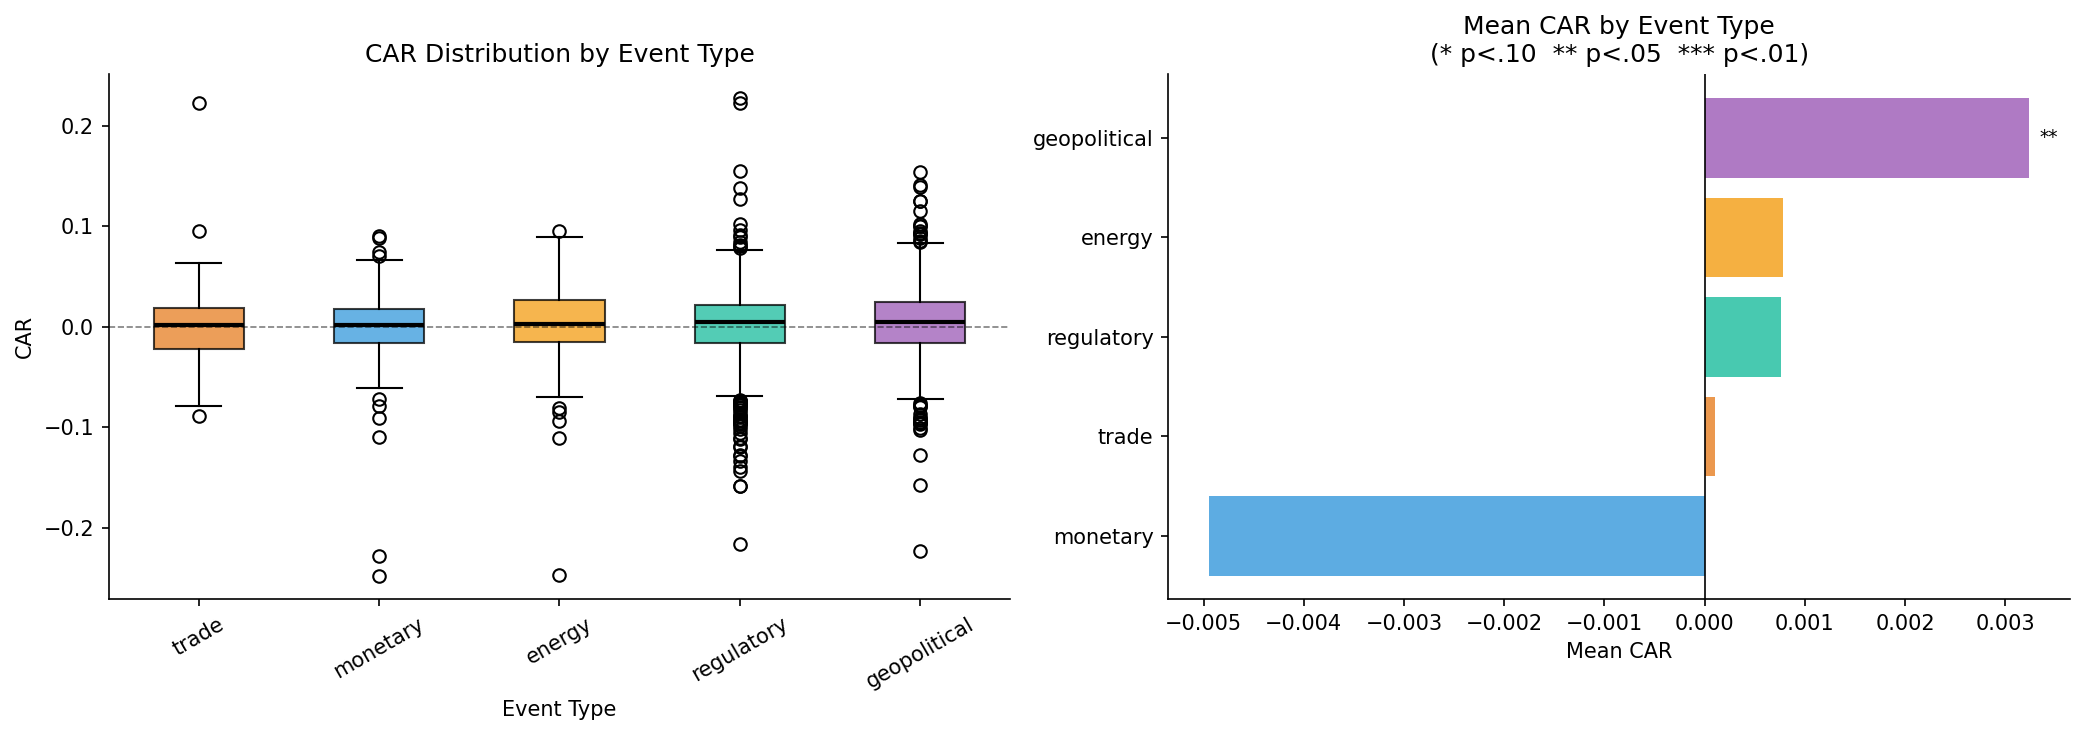

✓ Saved 04a_car_by_event_type.png


In [21]:
# ── Figure 04a: CAR distributions by event type ───────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: Box plots
ax = axes[0]
order = car_df.groupby('event_type')['car'].median().sort_values().index.tolist()
data_by_type = [car_df[car_df['event_type'] == et]['car'].dropna().values for et in order]
bp = ax.boxplot(data_by_type, labels=order, patch_artist=True,
                medianprops={'color': 'black', 'linewidth': 2})
for patch, etype in zip(bp['boxes'], order):
    patch.set_facecolor(COLOURS.get(etype, '#bdc3c7'))
    patch.set_alpha(0.75)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xlabel('Event Type')
ax.set_ylabel('CAR')
ax.set_title('CAR Distribution by Event Type')
ax.tick_params(axis='x', rotation=30)

# Panel 2: Mean CAR bar with significance
ax2 = axes[1]
sig_df = pd.DataFrame(sig_results).sort_values('mean_car')
colors = [COLOURS.get(et, '#bdc3c7') for et in sig_df['event_type']]
ax2.barh(sig_df['event_type'], sig_df['mean_car'], color=colors, alpha=0.8)
for i, (_, row) in enumerate(sig_df.iterrows()):
    marker = '***' if row['t_p'] < 0.01 else ('**' if row['t_p'] < 0.05 else ('*' if row['t_p'] < 0.10 else ''))
    if marker:
        x_off = 0.0001 if row['mean_car'] >= 0 else -0.0001
        ax2.text(row['mean_car'] + x_off, i, marker, va='center', fontsize=9)
ax2.axvline(0, color='black', linewidth=0.8)
ax2.set_xlabel('Mean CAR')
ax2.set_title('Mean CAR by Event Type\n(* p<.10  ** p<.05  *** p<.01)')

plt.tight_layout()
plt.savefig(FIGS / '04a_car_by_event_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 04a_car_by_event_type.png')

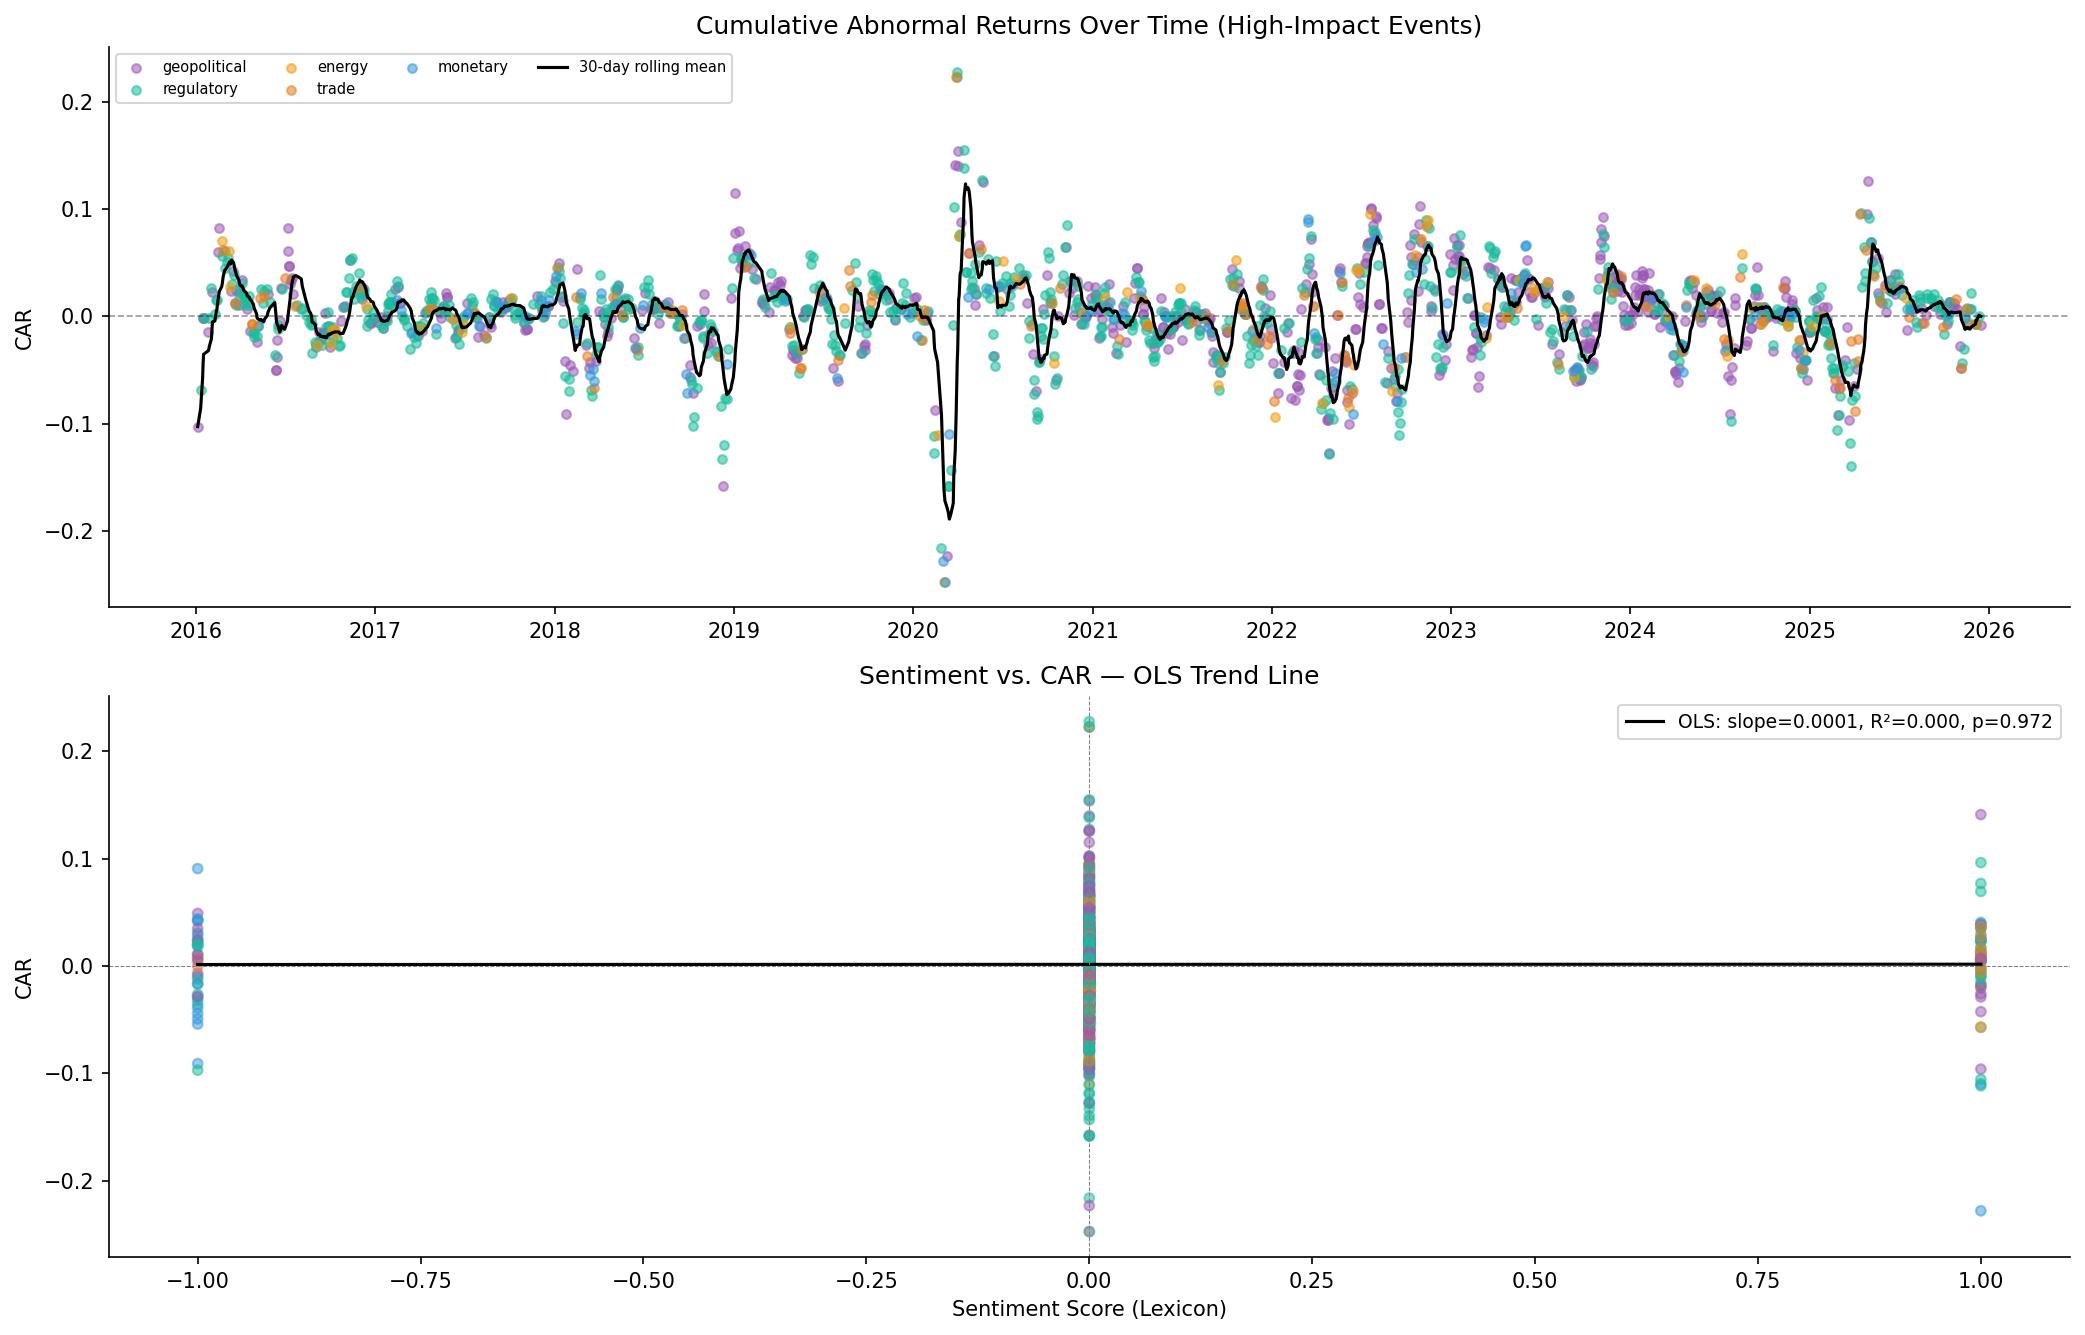

✓ Saved 04b_car_sentiment_scatter.png


In [22]:
# ── Figure 04b: CAR timeline + sentiment vs CAR scatter ───────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 9))

# Panel 1: CAR scatter over time
ax = axes[0]
for etype in car_df['event_type'].unique():
    sub = car_df[car_df['event_type'] == etype].sort_values('date')
    ax.scatter(sub['date'], sub['car'], label=etype,
               color=COLOURS.get(etype, '#bdc3c7'), alpha=0.55, s=18)
ax.axhline(0, color='black', linewidth=0.8, linestyle='--', alpha=0.4)
car_ts      = car_df.set_index('date')['car'].sort_index()
rolling_car = car_ts.rolling('30D').mean()
ax.plot(rolling_car.index, rolling_car.values, color='black',
        linewidth=1.5, label='30-day rolling mean', zorder=5)
ax.set_ylabel('CAR')
ax.set_title('Cumulative Abnormal Returns Over Time (High-Impact Events)')
ax.legend(fontsize=7, ncol=4, loc='upper left')

# Panel 2: Sentiment vs CAR with OLS
ax2 = axes[1]
valid = car_df.dropna(subset=['sentiment_numeric', 'car'])
ax2.scatter(valid['sentiment_numeric'], valid['car'],
            c=[COLOURS.get(et, '#bdc3c7') for et in valid['event_type']],
            alpha=0.5, s=22)
x = valid['sentiment_numeric'].values
y = valid['car'].values
if len(x) > 10:
    slope, intercept, r, p, _ = stats.linregress(x, y)
    x_line = np.linspace(x.min(), x.max(), 100)
    ax2.plot(x_line, intercept + slope * x_line, color='black', linewidth=1.5,
             label=f'OLS: slope={slope:.4f}, R²={r**2:.3f}, p={p:.3f}')
    ax2.legend(fontsize=9)
ax2.axhline(0, color='grey', linewidth=0.5, linestyle='--')
ax2.axvline(0, color='grey', linewidth=0.5, linestyle='--')
ax2.set_xlabel('Sentiment Score (Lexicon)')
ax2.set_ylabel('CAR')
ax2.set_title('Sentiment vs. CAR — OLS Trend Line')

plt.tight_layout()
plt.savefig(FIGS / '04b_car_sentiment_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 04b_car_sentiment_scatter.png')

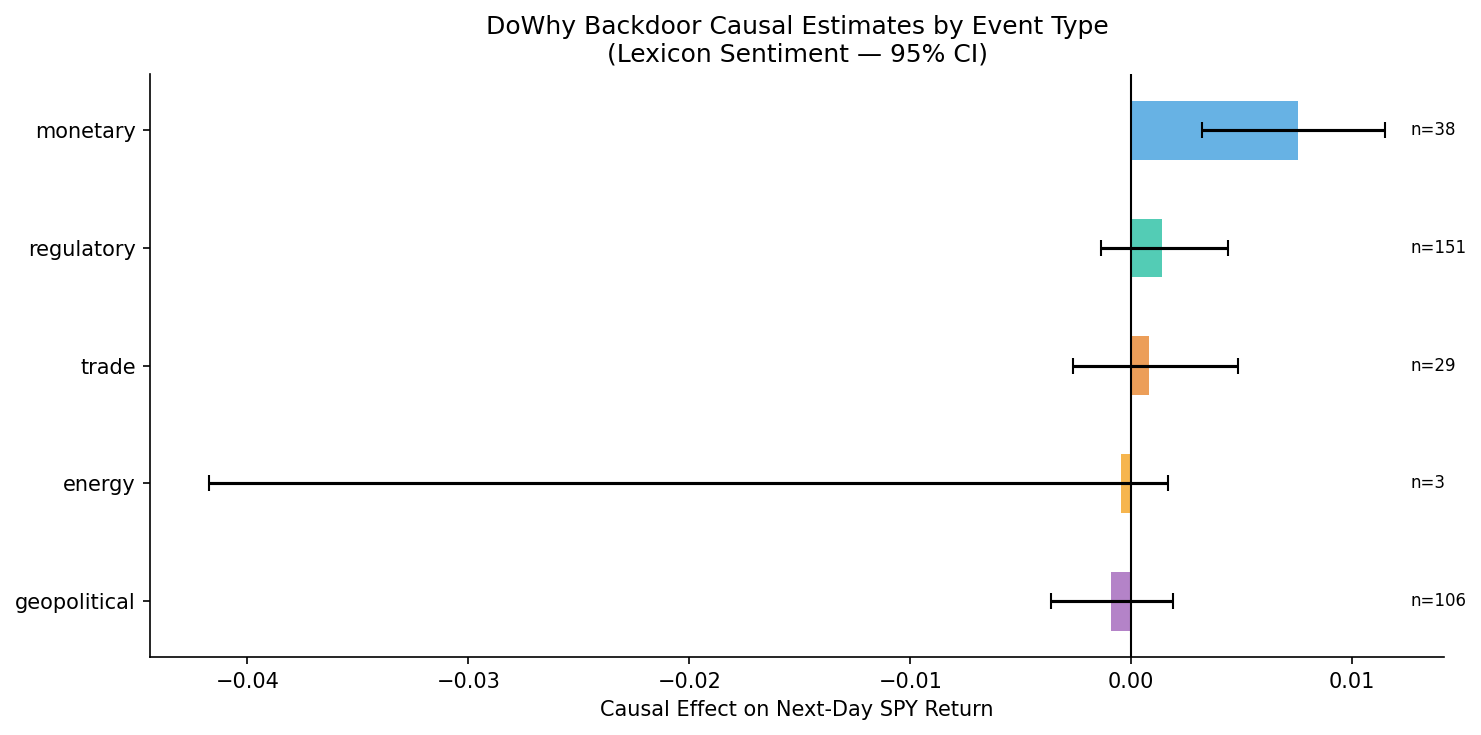

✓ Saved 04c_causal_estimates.png


In [23]:
# ── Figure 04c: DoWhy causal estimates with 95% CI ────────────────────
if DOWHY_AVAILABLE and len(causal_estimates) > 0:
    est_df = causal_est_df.sort_values('causal_effect')
    fig, ax = plt.subplots(figsize=(10, 5))
    y_pos   = list(range(len(est_df)))
    colors  = [COLOURS.get(et, '#bdc3c7') for et in est_df['event_type']]
    ax.barh(y_pos, est_df['causal_effect'], color=colors, alpha=0.75, height=0.5)
    ax.errorbar(
        est_df['causal_effect'], y_pos,
        xerr=[est_df['causal_effect'] - est_df['ci_lower'],
              est_df['ci_upper'] - est_df['causal_effect']],
        fmt='none', color='black', capsize=4, linewidth=1.5
    )
    ax.set_yticks(y_pos)
    ax.set_yticklabels(est_df['event_type'])
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('Causal Effect on Next-Day SPY Return')
    ax.set_title('DoWhy Backdoor Causal Estimates by Event Type\n(Lexicon Sentiment — 95% CI)')
    for i, (_, row) in enumerate(est_df.iterrows()):
        ax.text(est_df['ci_upper'].max() * 1.1, i,
                f"n={int(row['n_nonzero'])}", va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGS / '04c_causal_estimates.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('✓ Saved 04c_causal_estimates.png')
else:
    print('Skipping 04c — DoWhy not available or no estimates computed.')

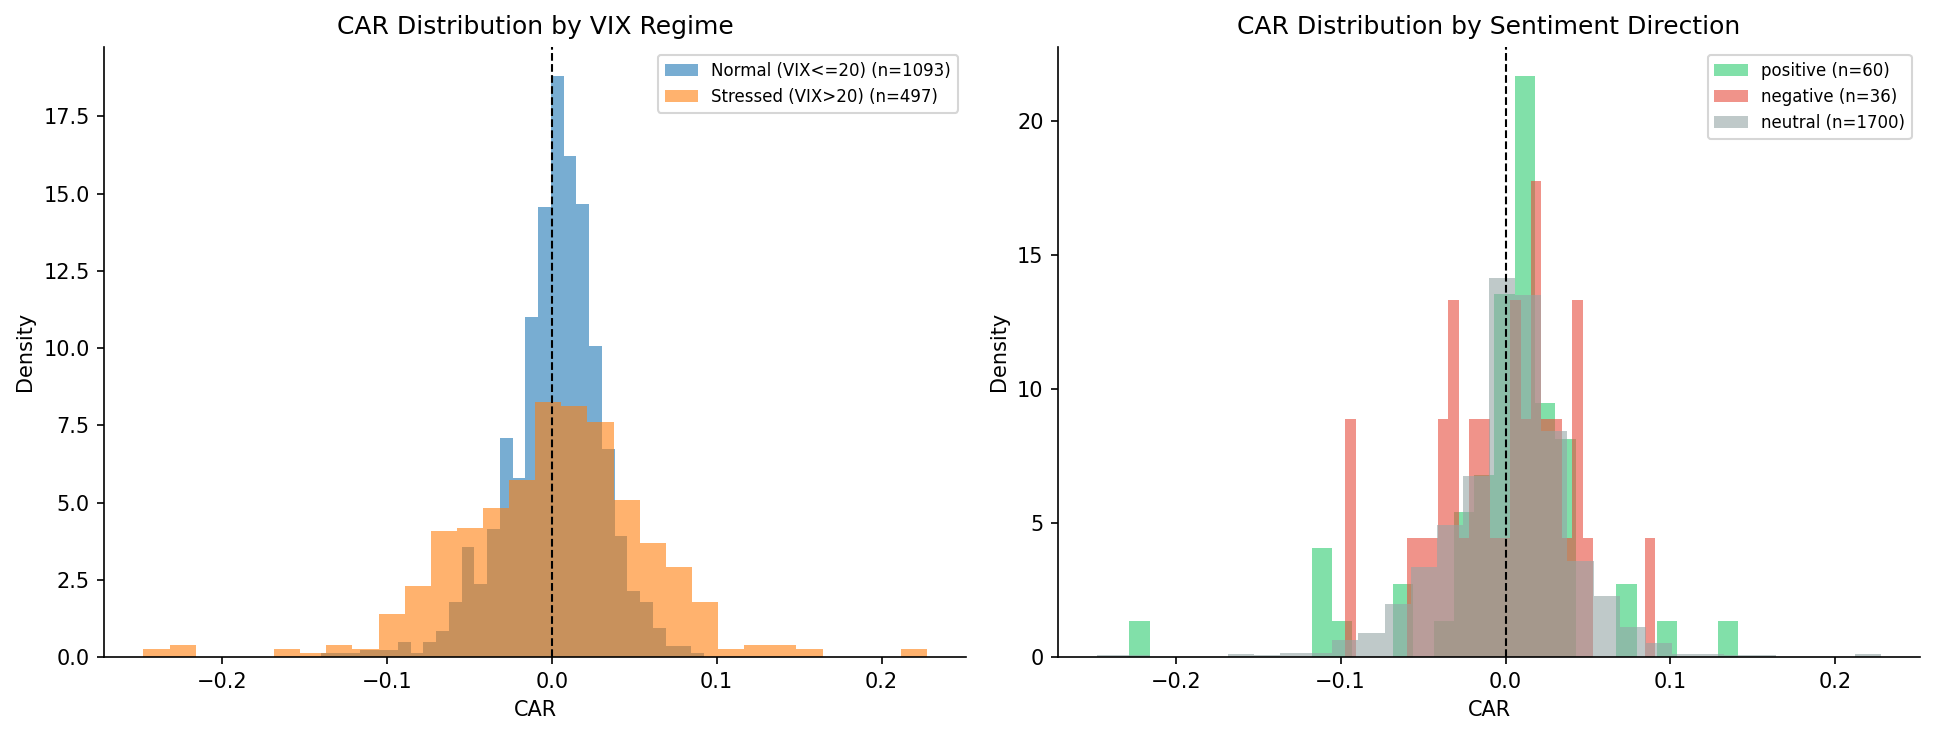

✓ Saved 04d_car_regime_sentiment.png


In [24]:
# ── Figure 04d: CAR by VIX regime and sentiment direction ─────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Panel 1: CAR by VIX regime
ax = axes[0]
car_vix = car_df.dropna(subset=['car','vix']).copy()
car_vix['regime'] = (car_vix['vix'] > 20).map({True: 'Stressed (VIX>20)', False: 'Normal (VIX<=20)'})
for regime, grp in car_vix.groupby('regime'):
    ax.hist(grp['car'].dropna(), bins=30, alpha=0.6,
            label=f"{regime} (n={len(grp)})", density=True)
ax.axvline(0, color='black', linewidth=1, linestyle='--')
ax.set_xlabel('CAR')
ax.set_ylabel('Density')
ax.set_title('CAR Distribution by VIX Regime')
ax.legend(fontsize=8)

# Panel 2: CAR by sentiment direction
ax2 = axes[1]
for label, col in [('positive','#2ecc71'), ('negative','#e74c3c'), ('neutral','#95a5a6')]:
    grp = car_df[car_df['sentiment_label'] == label]['car'].dropna()
    if len(grp) > 0:
        ax2.hist(grp, bins=30, alpha=0.6, color=col,
                 label=f"{label} (n={len(grp)})", density=True)
ax2.axvline(0, color='black', linewidth=1, linestyle='--')
ax2.set_xlabel('CAR')
ax2.set_ylabel('Density')
ax2.set_title('CAR Distribution by Sentiment Direction')
ax2.legend(fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / '04d_car_regime_sentiment.png', dpi=150, bbox_inches='tight')
plt.show()
print('✓ Saved 04d_car_regime_sentiment.png')

---
## Section 8 — Save Outputs

In [25]:
# ── CAR results ───────────────────────────────────────────────────────
car_out = car_df[[
    'date','event_type','president','sentiment_label','sentiment_numeric',
    'car','mean_ar','n_event_days','n_est_days',
    't_stat','p_value','significant','vix','overall_mean_sentiment'
]].copy()
car_out.to_parquet(PROC / 'car_results.parquet', index=False)
print(f'✓ car_results.parquet saved       — {len(car_out):,} rows')

# ── Causal estimates ──────────────────────────────────────────────────
if DOWHY_AVAILABLE and len(causal_estimates) > 0:
    causal_est_df.to_parquet(PROC / 'causal_estimates.parquet', index=False)
    print(f'✓ causal_estimates.parquet saved  — {len(causal_est_df)} event types')
else:
    print('⚠ causal_estimates.parquet not saved (DoWhy unavailable)')

✓ car_results.parquet saved       — 1,796 rows
✓ causal_estimates.parquet saved  — 5 event types


In [26]:
# ── Validation checks (Final Notebook Alignment, 2026-07-06) ──────────
# Lightweight, read-only checks on this notebook's own outputs — mirrors the
# validation discipline established in 03_event_detection.ipynb. Does not
# alter car_results.parquet / causal_estimates.parquet in any way.
print('=' * 65)
print('VALIDATION CHECKS — car_results.parquet / causal_estimates.parquet')
print('=' * 65)

_car_check = pd.read_parquet(PROC / 'car_results.parquet')
print(f'car_results.parquet   : {len(_car_check):,} rows x {_car_check.shape[1]} cols')
print(f'  Null dates          : {_car_check["date"].isna().sum()}')
print(f'  Null CAR             : {_car_check["car"].isna().sum()}')
print(f'  Date range           : {_car_check["date"].min()} -> {_car_check["date"].max()}')
_dupe_key = ['date', 'event_type', 'president']
_dupes = _car_check.duplicated(subset=_dupe_key, keep=False).sum()
print(f'  Duplicate ({",".join(_dupe_key)}) rows : {_dupes}')

_causal_path = PROC / 'causal_estimates.parquet'
if _causal_path.exists():
    _causal_check = pd.read_parquet(_causal_path)
    print(f'\ncausal_estimates.parquet : {len(_causal_check):,} rows x {_causal_check.shape[1]} cols')
    print(f'  Event types covered      : {sorted(_causal_check["event_type"].unique().tolist())}')
    print(f'  Any null causal_effect   : {_causal_check["causal_effect"].isna().sum()}')
else:
    print('\n⚠ causal_estimates.parquet not found on disk (DoWhy may have been unavailable this run).')

print('\n✓ Validation checks complete — see 09_results_log.md for the authoritative frozen figures.')

VALIDATION CHECKS — car_results.parquet / causal_estimates.parquet
car_results.parquet   : 1,796 rows x 14 cols
  Null dates          : 0
  Null CAR             : 0
  Date range           : 2016-01-05 00:00:00 -> 2025-12-15 00:00:00
  Duplicate (date,event_type,president) rows : 0

causal_estimates.parquet : 5 rows x 7 cols
  Event types covered      : ['energy', 'geopolitical', 'monetary', 'regulatory', 'trade']
  Any null causal_effect   : 0

✓ Validation checks complete — see 09_results_log.md for the authoritative frozen figures.


In [27]:
# ── Post-save verification (Final Notebook Alignment, 2026-07-06) ─────
_expected_outputs = ['car_results.parquet', 'causal_estimates.parquet']
_figs = ['04a_car_by_event_type.png', '04b_car_sentiment_scatter.png',
         '04c_causal_estimates.png', '04d_car_regime_sentiment.png']

for _f in _expected_outputs:
    _p = PROC / _f
    print(f'  {_f:<30} {"FOUND" if _p.exists() else "MISSING"}')
for _f in _figs:
    _p = FIGS / _f
    print(f'  {_f:<30} {"FOUND" if _p.exists() else "MISSING"}')

  car_results.parquet            FOUND
  causal_estimates.parquet       FOUND
  04a_car_by_event_type.png      FOUND
  04b_car_sentiment_scatter.png  FOUND
  04c_causal_estimates.png       FOUND
  04d_car_regime_sentiment.png   FOUND


In [29]:
print('=' * 65)
print('PHASE 4 — CAUSAL ANALYSIS: SUMMARY')
print('=' * 65)

print(f'\nEVENT STUDY  [window: {EVENT_WINDOW[0]} to +{EVENT_WINDOW[1]} trading days]')
print(f'  Events analysed       : {len(car_df):,}')
print(f'  Mean CAR              : {car_df["car"].mean():.4f}')
print(f'  Median CAR            : {car_df["car"].median():.4f}')
print(f'  Significant (p<.05)   : {car_df["significant"].sum()}  ({100*car_df["significant"].mean():.1f}%)')

print(f'\nCAUSAL ESTIMATION  [DoWhy — Backdoor Linear Regression]')
if DOWHY_AVAILABLE:
    print(f'  Overall (Lexicon)     : {lexicon_estimate:+.6f}  CI=[{lexicon_ci[0]:+.6f}, {lexicon_ci[1]:+.6f}]')
    if finbert_estimate is not None:
        print(f'  Overall (FinBERT)     : {finbert_estimate:+.6f}  CI=[{finbert_ci[0]:+.6f}, {finbert_ci[1]:+.6f}]  [robustness]')
    if len(causal_estimates) > 0:
        print(f'\n  By event type (Lexicon):')
        for _, row in causal_est_df.sort_values('causal_effect').iterrows():
            print(f'    {row["event_type"]:<15} {row["causal_effect"]:+.6f}  CI=[{row["ci_lower"]:+.6f}, {row["ci_upper"]:+.6f}]')
else:
    print('  DoWhy not available — install with: pip install dowhy')

print(f'\nREFUTATION TESTS')
if DOWHY_AVAILABLE and refutation_results:
    for name in refutation_results:
        print(f'  {name}: run')
else:
    print('  Not run')

print(f'\nOUTPUTS  ->  data/processed/')
print(f'  car_results.parquet        — {len(car_out):,} event CAR records')
if DOWHY_AVAILABLE and len(causal_estimates) > 0:
    print(f'  causal_estimates.parquet   — {len(causal_est_df)} event type estimates')

print(f'\nFIGURES  ->  reports/figures/')
for fig_name in ['04a_car_by_event_type.png','04b_car_sentiment_scatter.png',
                 '04c_causal_estimates.png','04d_car_regime_sentiment.png']:
    print(f'  {fig_name}')

print(f'\nKEY NOTES')
print(
    "  • Lexicon was used as the treatment variable for these already-frozen "
    "causal estimates (27% non-neutral vs. 5% FinBERT). "
    "This reflects the pre-SEF v1.0 methodology only. "
    "FinBERT is now the project's official primary sentiment engine "
    "(see 10_decision_log.md)."
)
print(f'  • FinBERT repeated as robustness check — compare estimates for consistency.')
print(f'  • VIX regime included as confounder (stressed markets amplify event impact).')
print(f'  • GDELT excluded as confounder (5-day sample insufficient for daily modelling).')
print(f'  • Refutation tests validate estimates are not spurious.')

print(f'\nNEXT: Phase 05 — Feature Engineering')
print('=' * 65)

PHASE 4 — CAUSAL ANALYSIS: SUMMARY

EVENT STUDY  [window: -5 to +10 trading days]
  Events analysed       : 1,796
  Mean CAR              : 0.0014
  Median CAR            : 0.0042
  Significant (p<.05)   : 87  (4.8%)

CAUSAL ESTIMATION  [DoWhy — Backdoor Linear Regression]
  Overall (Lexicon)     : +0.005032  CI=[+0.001371, +0.008694]
  Overall (FinBERT)     : +0.004916  CI=[+0.000671, +0.009322]  [robustness]

  By event type (Lexicon):
    geopolitical    -0.000896  CI=[-0.003632, +0.001905]
    energy          -0.000477  CI=[-0.041732, +0.001666]
    trade           +0.000815  CI=[-0.002615, +0.004826]
    regulatory      +0.001413  CI=[-0.001385, +0.004395]
    monetary        +0.007530  CI=[+0.003223, +0.011488]

REFUTATION TESTS
  random_common_cause: run
  placebo_treatment: run
  data_subset_80pct: run

OUTPUTS  ->  data/processed/
  car_results.parquet        — 1,796 event CAR records
  causal_estimates.parquet   — 5 event type estimates

FIGURES  ->  reports/figures/
  04a_ca

## Section Summary & Handoff to Notebook 05

Notebook 04 performs the event study and causal analysis stages of the pipeline only — it does not detect events, engineer predictive features, or train any model. Its outputs (`car_results.parquet`, `causal_estimates.parquet`) are the primary RQ1 evidence base and are treated as frozen; this alignment pass fixed a `vix.parquet` schema-drift bug (`vix` → `vix_close`, same root cause as Notebook 03's `fomc_dates.parquet` fix) and added the purpose/scope/interpretation/validation structure used throughout this Research Bible, but did not re-run the notebook or change any reported number — see `10_decision_log.md` (Final Notebook Alignment entry).

Notebook 05 (`05_feature_engineering.ipynb`) consumes this notebook's `car_results.parquet` output (event-derived features) alongside `master_dataset.parquet` and `daily_sentiment.parquet` — see that notebook's own scope note for its relationship to the frozen `feature_matrix.parquet` (FES v1.0).